In [1]:
import ast
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts
from scipy import stats
import seaborn as sns

In [5]:
def map_0_1(x):
    return [int(i == 1) for i in x]

main_dir = '../../'
file_mapping = {
    'ravi_qcnn_1348': main_dir + 'qcnn/experiments/exp11_immuno_ravi_bms_riaz/1348_binding_ravi.pkl',
    'ravi_qcnn_2456': main_dir + 'qcnn/experiments/exp11_immuno_ravi_bms_riaz/2456_immuno_binders_ravi.pkl',
    
    'ravi_ccnn_limited_1348': main_dir + 'ccnn/output/limited_params/survival_results/1348_binding_ravi/results.csv',
    'ravi_ccnn_limited_2456': main_dir + 'ccnn/output/limited_params/survival_results/2456_immuno_binders_ravi/results.csv',
    
    'ravi_ccnn_large_1348': main_dir + 'ccnn/output/large_params/survival_results/1348_binding_ravi/results.csv',
    'ravi_ccnn_large_2456': main_dir + 'ccnn/output/large_params/survival_results/2456_immuno_binders_ravi/results.csv',
    
    'ravi_rf_1348': main_dir + 'random_forest/experiments/binding_ravi_1348/pred_labels.pkl',
    'ravi_rf_2456': main_dir + 'random_forest/experiments/immuno_ravi_2456/pred_labels.pkl',
    
    'additional_preds': main_dir + 'qcnn/input_data/Ravi_Riaz_data/additonal_model_results/ravi_a0201_results_v2.csv',
    
    'ravi_data':main_dir +  'qcnn/input_data/Ravi_Riaz_data/Ravi_2023_NatGen_patient.txt',
    'ravi_tmb': main_dir + 'qcnn/input_data/Ravi_Riaz_data/Ravi_2023_NatGen_TMB.txt',
    'ravi_encoded': main_dir + 'qcnn/input_data/Ravi_Riaz_data/encoded_data/ravi_encoded_a0201.csv',    
    'ravi_ba': main_dir + 'qcnn/input_data/Ravi_Riaz_data/Ravi_2023_NatGen_samples_a0201_barank.csv',
}

# get predicted qcnn labels 
with open(file_mapping['ravi_qcnn_2456'], 'rb') as f:
    qcnn_2456 = np.array(map_0_1(pickle.load(f)['test_pred']))
with open(file_mapping['ravi_qcnn_1348'], 'rb') as f:
    qcnn_1348 = np.array(map_0_1(pickle.load(f)['test_pred']))
qcnn_comb_labels = qcnn_2456 & qcnn_1348



# load peptide samples & NetMHC labels
encoded_data = pd.read_csv(file_mapping[f'ravi_encoded'])
patients = encoded_data['Sample'].to_numpy()

netmhc_labels = encoded_data['BA_rank'].to_numpy()
netmhc_labels = [1 if i < 2 else 0 for i in netmhc_labels ]

print(f'Ravi --- Labels: {len(qcnn_comb_labels)} --- Patients: {len(set(patients))}')


# create df with patient id and qcnn_pred --> group by patient id and get the counts
df = pd.DataFrame({"patient": patients, "qcnn_2456": qcnn_2456,  "qcnn_1348": qcnn_1348, "qcnn_comb": qcnn_comb_labels, "netMHC_pred": netmhc_labels})
df = (
    df.groupby("patient").agg(
        qcnn_2456=("qcnn_2456", "sum"),
        qcnn_1348=("qcnn_1348", "sum"),
        qcnn_comb=("qcnn_comb", "sum"),
        netmhc=("netMHC_pred", "sum")
    ).reset_index()
)    

# ensure all patients are in the data frame (even if count is 0)
all_patients = pd.DataFrame({"patient": patients}).drop_duplicates()
df = (all_patients.merge(df, on="patient", how="left").fillna(0))


# get total number of peptides for each patient
patient_counts = pd.Series(patients).value_counts()
df['total_counts'] = df['patient'].map(patient_counts).fillna(0).astype(int)


# get ccnn labels:
if False:
    for model in ['ltd', 'large']:
        data = pd.read_csv(file_mapping[f'ravi_ccnn_{model}_1348'])
        ccnn_1348 = np.array(ast.literal_eval(data['pred_labels'][0]))
        data = pd.read_csv(file_mapping[f'ravi_ccnn_{model}_2456'])
        ccnn_2456 = np.array(ast.literal_eval(data['pred_labels'][0]))

        agg_dict = {
            f'ccnn_{model}_2456': (f'ccnn_{model}_2456', 'sum'),
            f'ccnn_{model}_1348': (f'ccnn_{model}_1348', 'sum'),
            f'ccnn_{model}_comb': (f'ccnn_{model}_comb', 'sum'),
        }

        ccnn_comb_labels = ccnn_2456 & ccnn_1348
        classical_df = pd.DataFrame({"patient": patients, f"ccnn_{model}_1348": ccnn_1348, f"ccnn_{model}_2456": ccnn_2456, f"ccnn_{model}_comb": ccnn_comb_labels})
        classical_df = (classical_df.groupby("patient").agg(**agg_dict).reset_index())
        df = pd.merge(df, classical_df, on="patient") 

    
    # get rf preds
    with open(file_mapping['rf_1348'], 'rb') as f:
        rf_1348 = pickle.load(f)['avg_pred_labels']
    with open(file_mapping['rf_2456'], 'rb') as f:
        rf_2456 = pickle.load(f)['avg_pred_labels']
    rf_labels = rf_2456 & rf_1348
    classical_df = pd.DataFrame({"patient": patients, "rf_1348": rf_1348, "rf_2456": rf_2456, "rf_comb": rf_labels.astype(int)})
    classical_df = (
        classical_df.groupby("patient").agg(
            rf_2456=("rf_2456", "sum"),
            rf_1348=("rf_1348", "sum"),
            rf_comb=("rf_comb", "sum"),
        ).reset_index()
    )    

    df = pd.merge(df, classical_df, on="patient")



# format to match the clinical data
df['patient'] = df['patient'].apply(lambda x: 'R23NG_' + x if not x.startswith('R23NG_') else x)
df['patient'] = df['patient'].apply(lambda x: x[:-3] if x.endswith('T1') else x)

# get the OS clinical data and map to each patient
data = pd.read_csv(file_mapping['ravi_data'], delimiter='\t')
tmb_data = pd.read_csv(file_mapping['ravi_tmb'], delimiter='\t')

sample_to_os_event = data.set_index('id')['os_status'].to_dict() # true = dead, false = alive
df['OS_event'] = df['patient'].map(sample_to_os_event)
df['OS_event'] = df['OS_event'].apply(lambda x: 1 if x == 'DECEASED' else 0)

sample_to_os_time = data.set_index('id')['os_months'].to_dict() # in months
df['OS_time'] = df['patient'].map(sample_to_os_time)

# true = progressed, false = not progressed
sample_to_pfs_event = data.set_index('id')['pfs_status'].to_dict()
df['PFS_event'] = df['patient'].map(sample_to_pfs_event)
df['PFS_event'] = df['PFS_event'].apply(lambda x: 1 if x == 'PROGRESSED' else 0)

# in months
sample_to_pfs_time = data.set_index('id')['pfs_months'].to_dict()
df['PFS_time'] = df['patient'].map(sample_to_pfs_time)

sample_to_recist = data.set_index('id')['recist'].to_dict()
df['recist'] = df['patient'].map(sample_to_recist)

sample_to_tmb = tmb_data.set_index('Tumor_Sample_Barcode')['total_perMB']
df['patient_tmb'] = [i.split('_')[1] + '-T1' for i in df['patient']]
df['TMB'] = df['patient_tmb'].map(sample_to_tmb)

# filter patients without data
df = df.dropna(subset=['OS_time', 'PFS_time'])

# load other models preds: 'X.Rank_A0201(PRIME)', 'prank.MSi_A0201(HLAthena)', 'mhcflurry_presentation_percentile'
additional_df = pd.read_csv(file_mapping['additional_preds'])[['Sample', 'Peptide', 'X.Rank_A0201', 'prank.MSi_A0201', 'mhcflurry_presentation_percentile', 'predicted_NeoFitness']]
additional_df['patient'] = ['R23NG_' + i for i in additional_df['Sample']]
additional_df['patient'] = ['-'.join(i.split('-')[:-1])for i in additional_df['patient']]
additional_df['X.Rank_A0201_counts'] = [int(i < 2.0) for i in additional_df['X.Rank_A0201']]
additional_df['prank.MSi_A0201_counts'] = [int(i < 0.5) for i in additional_df['prank.MSi_A0201']]
additional_df['mhcflurry_presentation_percentile_counts'] = [int(i < 2.0) for i in additional_df['mhcflurry_presentation_percentile']]
additional_df['predicted_NeoFitness'] = [1 if i == 'Immunogenic' else 0 for i in additional_df['predicted_NeoFitness']]

additional_agg = (
    additional_df.groupby("patient").agg(
        prime=("X.Rank_A0201_counts", "sum"),
        hlathena=("prank.MSi_A0201_counts", "sum"),
        mhcflurry=("mhcflurry_presentation_percentile_counts", "sum"),
        neoFitness=("predicted_NeoFitness", "sum")
    ).reset_index())
df = pd.merge(df, additional_agg, on="patient", how="left")

count_labels = ['qcnn_1348', 'qcnn_2456', 'qcnn_comb','netmhc', 'prime', 'hlathena', 'mhcflurry', 'neoFitness']
for label in count_labels:
    df[f'{label}_tmb_normalized'] = df[label] / df['TMB']
    df[f'{label}_std'] = stats.zscore(df[label])
    df[f'{label}_tmb_normalized_std'] = stats.zscore(df[f'{label}_tmb_normalized'])

df.head()

Ravi --- Labels: 209889 --- Patients: 111


,patient,qcnn_2456,qcnn_1348,qcnn_comb,netmhc,total_counts,OS_event,OS_time,PFS_event,PFS_time,...,prime_tmb_normalized_std,hlathena_tmb_normalized,hlathena_std,hlathena_tmb_normalized_std,mhcflurry_tmb_normalized,mhcflurry_std,mhcflurry_tmb_normalized_std,neoFitness_tmb_normalized,neoFitness_std,neoFitness_tmb_normalized_std
0,R23NG_SU2CLC-DFC-DF0899,1096,1031,444,103,2505,1,17.971253,1,5.486653,...,-0.208623,0.707965,-0.222850,-0.810262,14.778761,0.271262,0.299847,5.840708,0.612013,1.139278
1,R23NG_SU2CLC-DFC-DF0648,483,440,191,41,1127,0,11.498973,0,11.498973,...,0.170609,1.687500,-0.142989,0.982657,12.750000,-0.408037,-0.503944,6.187500,-0.121767,1.380410
2,R23NG_SU2CLC-YAL-2511,189,180,68,15,475,1,7.129363,1,1.478439,...,0.707435,0.952381,-0.702017,-0.362888,17.142857,-0.627608,1.236497,3.333333,-0.699897,-0.604156
3,R23NG_SU2CLC-MGH-1492,506,435,182,50,1111,0,4.139630,1,2.365503,...,0.560350,1.800000,-0.142989,1.188574,14.400000,-0.380590,0.149783,3.400000,-0.477539,-0.557802
4,R23NG_SU2CLC-DFC-DF0908,669,658,292,53,1548,0,9.659138,0,8.804928,...,-0.770573,1.085973,-0.222850,-0.118365,13.438914,-0.195327,-0.230997,3.665158,-0.255182,-0.373431


In [ ]:
# get predicted qcnn labels 
ccnn_ltd_2456 = pd.read_csv(ile_mapping['ravi_ccnn_limited_2456'])
ccnn_ltd_1348 = pd.read_csv(ile_mapping['ravi_ccnn_limited_1348'])['']
ccnn_ltd_comb_labels = ccnn_ltd_2456 & ccnn_ltd_1348

In [3]:
labels = ['qcnn_2456', 'qcnn_1348', 'qcnn_comb','netmhc']

title_map = {
    'qcnn_2456': 'QCNN: 3,5,6,7 Immunogenicity',
    'qcnn_1348': 'QCNN: 2,4,5,9 Binding',
    'qcnn_comb': 'Q-CHIPP',
     
    'netmhc': 'NetMHC',
    'prime': 'PRIME', 
    'hlathena': 'HLAthena', 
    'mhcflurry': 'MHCflurry',
    'neoFitness': 'NeoFitness',
    'TMB': 'TMB',

    'tmb_normalized': 'TMB Normalized',
    'std': 'Z-Score Normalized',
    'tmb_normalized_std': 'Z-Score Normalized (TMB Normalized)',
    '': 'Raw Counts'
}

KeyError: 'qcnn_2456_tmbn_normalized'

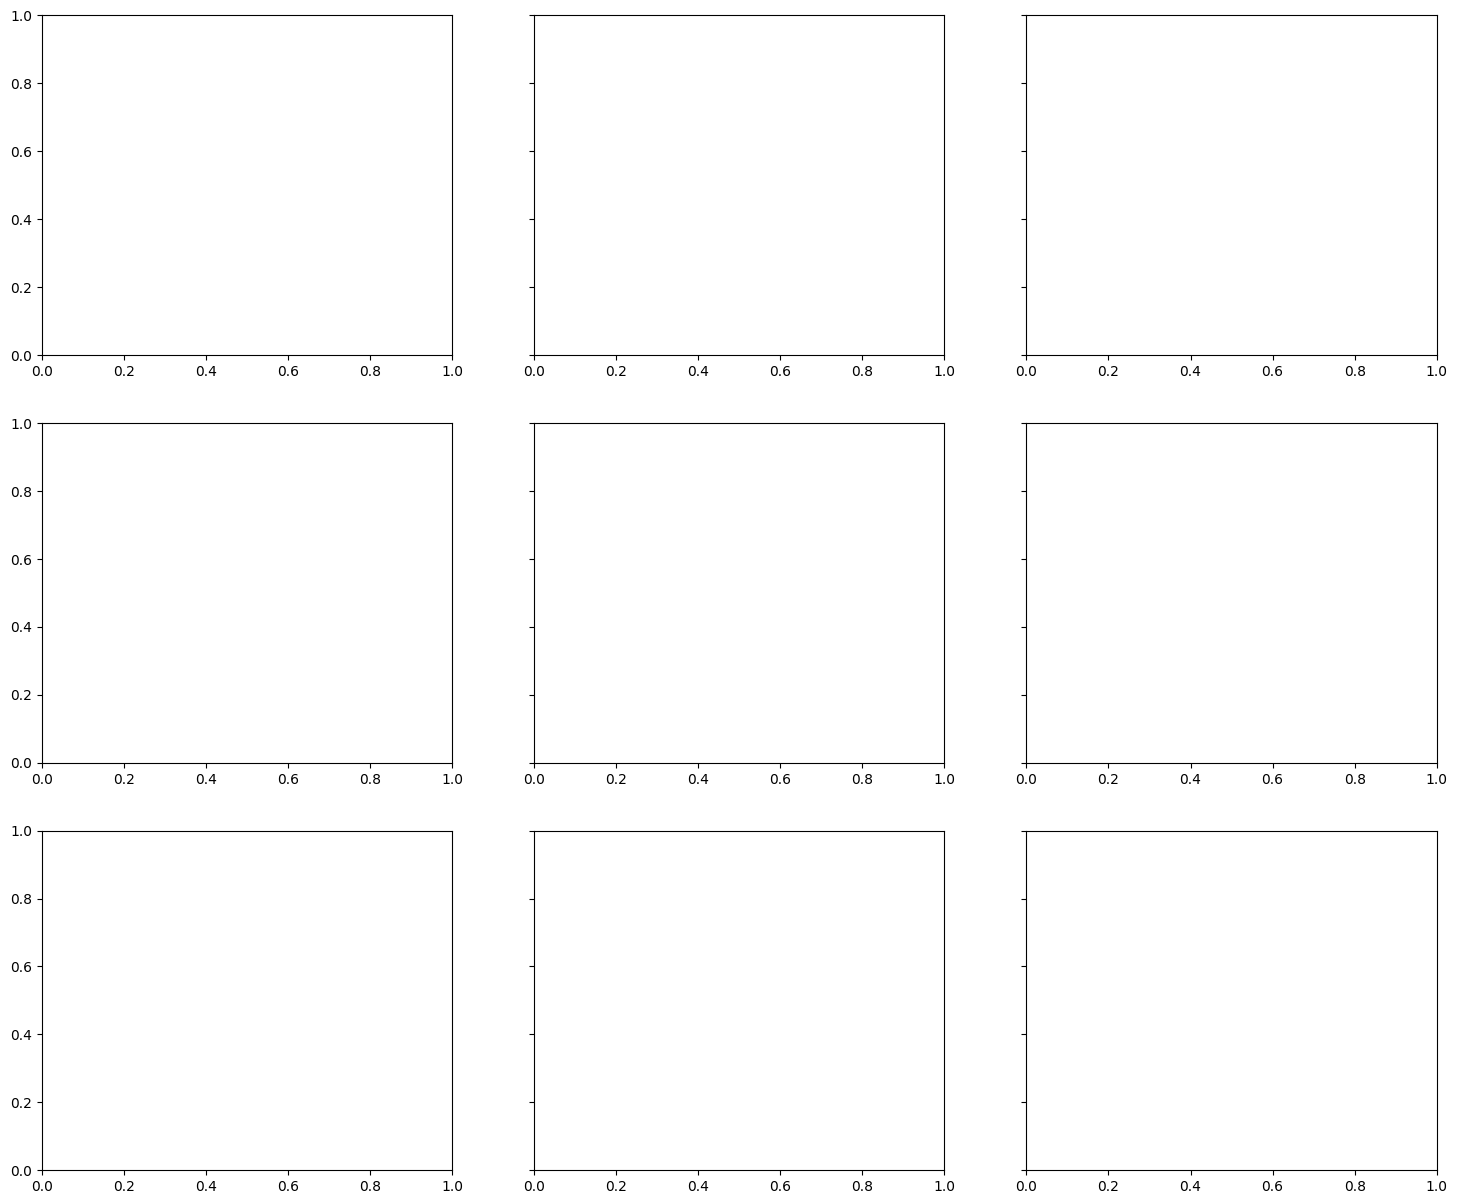

In [4]:
# plot each survival curve
count_type = '' # options: 'std', 'tmb_normalized', 'tmb_normalized_std', ''
continuous = False
metric = 'OS'  # options: 'OS', 'PFS'

time = f'{metric}_time'
event = f'{metric}_event'
fig, axs = plt.subplots(3, 3, figsize=(18, 15), sharey=True)
hazard_ratios = {}
for i, label in enumerate(labels):
    count_label = f'{label}_{count_type}' if count_type != '' else label

    print(f"Mean: {df[count_label].mean()}, Std: {df[count_label].std()}")

    median = np.median(df[count_label])
    threshold = median
    print(f'Test: Ravi, Label: {count_label}, Median: {median}')

    df['group'] = (df[count_label] >= threshold).astype(int) # 1 = High, 0 = Low
    
    # Fit Cox Proporital Hazards Model
    cph = CoxPHFitter()
    cph_data = df[[time, event, 'group']].copy()
    cph.fit(cph_data, duration_col=time, event_col=event)
    hr = cph.hazard_ratios_['group']
    p_hr = cph.summary.loc['group', 'p']
    ci_lower = cph.summary.loc['group', 'exp(coef) lower 95%']
    ci_upper = cph.summary.loc['group', 'exp(coef) upper 95%']
    hazard_ratios[label] = ({'hr': hr, 'p_hr': p_hr, 'CI_lower': ci_lower, 'CI_upper':ci_upper})
    
    # split data for KM plot
    high_group = df[df['group'] == 1]
    low_group = df[df['group'] == 0]
    
    # Create the KMF instances
    kmf_high = KaplanMeierFitter()
    kmf_low = KaplanMeierFitter()

    # Fit the data
    kmf_high.fit(high_group[time], event_observed=high_group[event], label='High')
    kmf_low.fit(low_group[time], event_observed=low_group[event], label='Low')

    # Perform log-rank test for p-value
    results = logrank_test(
        high_group[time], low_group[time],
        event_observed_A=high_group[event],
        event_observed_B=low_group[event]
    )
    p_value = results.p_value
    print(f'{metric}: {p_value}')


    ax = axs[i // 3, i % 3]
    ax.text(-0.05, 1.15, chr(65 + i), transform=ax.transAxes,
        fontsize=18, va='top', ha='left')
    kmf_high.plot_survival_function(ax=ax, ci_show=False)
    kmf_low.plot_survival_function(ax=ax, ci_show=False)
    ax.set_title(f'{title_map[label]}')
    ax.set_xlabel('Time (months)')
    ax.set_ylabel('Survival Probability')
    
    # display p-value
    ax.text(0.02, 0.05, f'p = {p_value:.4f}', transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='left',
        fontsize=12, bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

    # Add risk table below the plot
    add_at_risk_counts(kmf_high, kmf_low, ax=ax)
    
for j in range(len(labels), axs.size):
    axs.flat[j].set_visible(False)
    
subtitle = f'{metric}' if count_type == '' else f'{metric} - {title_map[count_type]}'
#fig.suptitle(f'Survival Analysis: {subtitle}', fontsize=16, fontweight='bold') # , {title_map[count_type]}
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('survival_plots_abcd.svg', dpi=300, bbox_inches='tight')
plt.show()